### Phase 1: Structural demand and elasticity validation

In this phase, we focus on validating whether the simulated environment produces economically consistent and statistically identifiable demand behavior. Building on the exploratory analysis, the objective is to ensure that the underlying demand function can be reliably learned from data, particularly with respect to price elasticity and key market drivers.

This phase therefore emphasizes isolating the core economic relationships embedded in the simulation. Specifically, we aim to verify that:
- Demand responds negatively and nonlinearly to price;
- Price elasticity behaves consistently across different demand regimes;
- Seasonal effects shift demand levels in a stable and learnable manner;
- The system remains identifiable when excluding redundant or state-driven features.


In [15]:
import pickle
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pygam import LinearGAM, s
from sklearn.preprocessing import StandardScaler

random.seed(42)
np.random.seed(42)
rng = np.random.default_rng()

In [16]:
df = pd.read_csv("data/phase_0.csv", parse_dates=["date"])

df["rel_price"] = np.clip(np.log(df["price_competitor"]) - np.log(df["price_agent"]), -0.8, 0.8)
df["competitor_lag_1"] = df["price_competitor"].shift(1)
df["rel_price_lag_1"] = df["rel_price"].shift(1)
df["price_lag_1"] = df["price_agent"].shift(1)
df["lag_1"] = df["realized_demand"].shift(1)

df = df[df["realized_demand"] > 0].copy()
df = df.dropna().reset_index(drop=True)

print(df.shape)
df.tail()

(90, 12)


,date,price_agent,price_competitor,season_signal,demand_shock,realized_demand,revenue,rel_price,competitor_lag_1,rel_price_lag_1,price_lag_1,lag_1
85,2025-03-28,121.440457,128.812906,8.406654e-06,-0.113406,14.904834,715.759816,0.058937,122.370122,0.028706,118.907362,13.795989
86,2025-03-29,137.572785,130.031039,2.958194e-06,-0.176007,7.698805,397.217781,-0.056380,128.812906,0.058937,121.440457,14.904834
87,2025-03-30,135.538258,132.051480,9.956995e-07,-0.394795,6.949169,324.928128,-0.026062,130.031039,-0.056380,137.572785,7.698805
88,2025-03-31,142.179888,138.322897,3.205737e-07,-0.337373,6.561266,339.204082,-0.027502,132.051480,-0.026062,135.538258,6.949169
89,2025-04-01,133.522361,141.209000,8.713244e-01,-0.356152,16.178875,989.509104,0.055972,138.322897,-0.027502,142.179888,6.561266


In [17]:
df[["realized_demand", "price_agent", "price_competitor", "rel_price",
    "season_signal", "lag_1", "price_lag_1", "competitor_lag_1",
    "rel_price_lag_1"]].corr()

,realized_demand,price_agent,price_competitor,rel_price,season_signal,lag_1,price_lag_1,competitor_lag_1,rel_price_lag_1
realized_demand,1.000000,-0.767286,0.229508,0.814325,0.294704,0.246317,-0.118988,0.032735,0.124933
price_agent,-0.767286,1.000000,0.225266,-0.629491,-0.145306,-0.048608,0.173548,0.344313,0.134426
price_competitor,0.229508,0.225266,1.000000,0.612311,-0.159946,0.131252,0.047193,0.515613,0.366252
rel_price,0.814325,-0.629491,0.612311,1.000000,-0.016472,0.160464,-0.122976,0.122646,0.193181
season_signal,0.294704,-0.145306,-0.159946,-0.016472,1.000000,0.250449,-0.118692,-0.185174,-0.059045
lag_1,0.246317,-0.048608,0.131252,0.160464,0.250449,1.000000,-0.753708,0.196223,0.776324
price_lag_1,-0.118988,0.173548,0.047193,-0.122976,-0.118692,-0.753708,1.000000,0.227430,-0.625800
competitor_lag_1,0.032735,0.344313,0.515613,0.122646,-0.185174,0.196223,0.227430,1.000000,0.614322
rel_price_lag_1,0.124933,0.134426,0.366252,0.193181,-0.059045,0.776324,-0.625800,0.614322,1.000000


In [18]:
df["log_price"] = np.log(df["price_agent"] / df["price_agent"].mean())
df["log_comp"] = np.log(df["price_competitor"] / df["price_competitor"].mean())

print("Log price var:", df["log_price"].var().round(4))
print("Comp price var:", df["log_comp"].var().round(4))

Log price var: 0.0162
Comp price var: 0.0153


In [19]:
print('Std:', df["price_agent"].std().round(4))
print('Mean:', df["price_agent"].mean().round(4))
print("Coef. var:", (df["price_agent"].std() / df["price_agent"].mean()).round(4))

Std: 16.5808
Mean: 134.7647
Coef. var: 0.123


In [20]:
print('Std:', df["price_competitor"].std().round(4))
print('Mean:', df["price_competitor"].mean().round(4))
print("Coef. var:", (df["price_competitor"].std() / df["price_competitor"].mean()).round(4))

Std: 16.0014
Mean: 137.4716
Coef. var: 0.1164


The correlation structure highlights several important relationships. Seasonality shows the strongest positive correlation with demand (~0.64), followed by lag (~0.44), confirming that both capture significant variation in baseline demand and persistence effects.

Agent price exhibits a near-zero correlation with demand (~0.07), suggesting that its effect is not easily captured through simple linear relationships and requires nonlinear modeling.

Relative price and competitor price are highly correlated with each other (~0.86), indicating strong multicollinearity and suggesting that they encode similar competitive information. Both show weak negative correlations with demand, reflecting substitution effects but with limited standalone explanatory power.

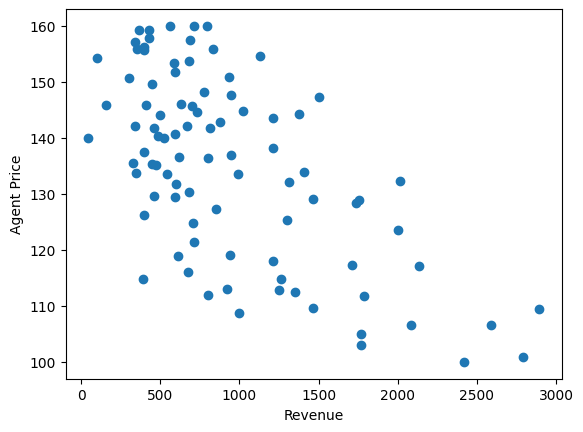

In [21]:
plt.scatter(df["revenue"], df["price_agent"])
plt.xlabel("Revenue")
plt.ylabel("Agent Price")
#plt.title("Evidence of a Nonlinear Pricing Trade-off")
plt.show()

In [29]:
df["state_bin"] = pd.qcut(df["season_signal"], 4)
df.groupby("state_bin")["price_agent"].describe()

C:\Users\Breno\AppData\Local\Temp\ipykernel_27252\3319917165.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("state_bin")["price_agent"].describe()


,count,mean,std,min,25%,50%,75%,max
state_bin,,,,,,,,
"(-0.000999679, 0.000362]",23.0,127.838218,17.020337,100.000000,113.782791,127.390207,140.361617,156.179151
"(0.000362, 0.0603]",22.0,141.659913,14.105410,111.712984,133.626887,143.239600,155.274146,160.000000
"(0.0603, 0.755]",22.0,139.888840,15.963617,100.875415,135.448668,143.833072,148.098591,160.000000
"(0.755, 1.174]",23.0,130.194444,15.605628,106.535056,115.979326,129.581751,139.997269,159.903610


The scatter plot illustrates the relationship between agent price and resulting revenue, highlighting a clear nonlinear trade-off. Revenue does not increase monotonically with price; instead, similar revenue levels are observed across a wide range of prices. This reflects the fundamental balance between price and demand: higher prices increase margin but reduce demand, while lower prices boost demand but compress margins.

The dispersion of points suggests the presence of an implicit optimal pricing region rather than a single optimal price. In some cases, relatively lower prices achieve comparable or even higher revenues than higher prices, indicating that demand responsiveness plays a critical role.

C:\Users\Breno\AppData\Local\Temp\ipykernel_27252\2534809518.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rev_effect = df.groupby(bins)["revenue"].mean()
C:\Users\Breno\AppData\Local\Temp\ipykernel_27252\2534809518.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  price_effect = df.groupby(bins)["price_agent"].mean()
C:\Users\Breno\AppData\Local\Temp\ipykernel_27252\2534809518.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(price_effect.values.astype(np.int16))


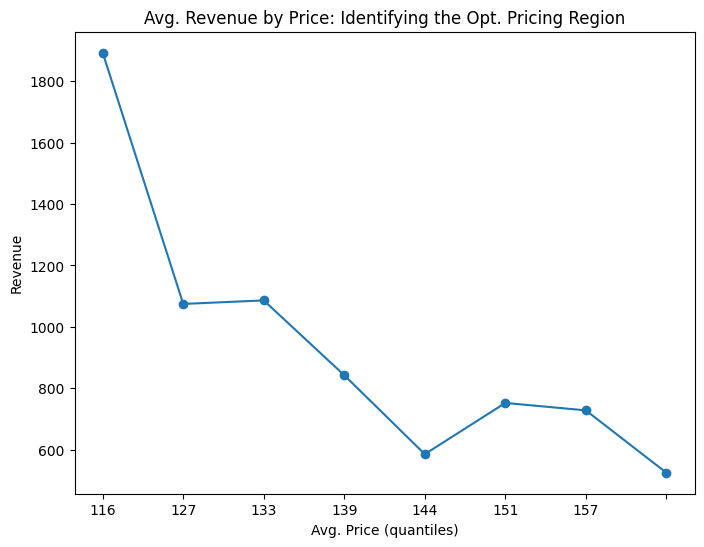

In [22]:
fig, ax = plt.subplots(figsize=(8, 6))

bins = pd.qcut(df["price_agent"], 8)
rev_effect = df.groupby(bins)["revenue"].mean()
price_effect = df.groupby(bins)["price_agent"].mean()

ax.set_xticklabels(price_effect.values.astype(np.int16))

plt.plot(rev_effect.values, marker="o")
plt.title("Revenue vs Price")
plt.xlabel("Avg. Price (quantiles)")
plt.ylabel("Revenue")

plt.title("Avg. Revenue by Price: Identifying the Opt. Pricing Region")
plt.show()

This plot shows the average revenue achieved at different price levels, revealing a clear nonlinear relationship. Revenue initially declines as price increases, suggesting that demand reduction outweighs margin gains in this range. However, beyond a certain point, revenue begins to recover and eventually increases, indicating that higher margins start compensating for lower demand.

The dip around the mid-price range highlights a suboptimal pricing region, while the upward trend at higher prices suggests the presence of a more profitable pricing zone. This pattern reflects the interaction between price elasticity and margin, where optimal pricing is not linear but depends on balancing demand sensitivity with per-unit profitability.

In [31]:
import numpy as np
import statsmodels.api as sm

df["log_demand"] = np.log(df["realized_demand"])

X = df[["log_price", "log_comp"]]
X = sm.add_constant(X) 

y = df["log_demand"]

model_struct = sm.OLS(y, X).fit()
model_struct.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:             log_demand   R-squared:                       0.830
Model:                            OLS   Adj. R-squared:                  0.826
Method:                 Least Squares   F-statistic:                     212.0
Date:                Tue, 07 Apr 2026   Prob (F-statistic):           3.57e-34
Time:                        05:12:03   Log-Likelihood:                -14.138
No. Observations:                  90   AIC:                             34.28
Df Residuals:                      87   BIC:                             41.78
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.6012      0.030     85.434      0.000       2.541       2.662
log_price     -4.8383      0.245    -19.733      0.000      -5.326      -4.351
log_comp       2.4553      0.252      9.736      0.000       1.954       2.957
==============================================================================
Omnibus:                        2.266   Durbin-Watson:                   0.525
Prob(Omnibus):                  0.322   Jarque-Bera (JB):                2.219
Skew:                           0.371   Prob(JB):                        0.330
Kurtosis:                       2.799   Cond. No.                         8.99
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [36]:
df["residuals"] = df["log_demand"] - model_struct.predict(X)
df[["residuals", "log_price", "log_comp"]].corr()

,residuals,log_price,log_comp
residuals,1.000000e+00,-7.944596e-16,-1.517968e-16
log_price,-7.944596e-16,1.000000e+00,2.012999e-01
log_comp,-1.517968e-16,2.012999e-01,1.000000e+00


In [38]:
df["latent_demand"] = df["residuals"].ewm(alpha=.3).mean()

X = df[["log_price", "log_comp", "latent_demand"]]
X = sm.add_constant(X) 

y = df["log_demand"]

model_struct = sm.OLS(y, X).fit()
model_struct.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:             log_demand   R-squared:                       0.955
Model:                            OLS   Adj. R-squared:                  0.954
Method:                 Least Squares   F-statistic:                     609.6
Date:                Tue, 07 Apr 2026   Prob (F-statistic):           8.22e-58
Time:                        05:22:28   Log-Likelihood:                 45.828
No. Observations:                  90   AIC:                            -83.66
Df Residuals:                      86   BIC:                            -73.66
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
=================================================================================
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const             2.5819      0.016    163.638      0.000       2.550       2.613
log_price        -4.8030      0.127    -37.913      0.000      -5.055      -4.551
log_comp          2.2340      0.131     17.046      0.000       1.973       2.495
latent_demand     1.0944      0.071     15.492      0.000       0.954       1.235
==============================================================================
Omnibus:                       15.772   Durbin-Watson:                   1.164
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               21.407
Skew:                           0.809   Prob(JB):                     2.25e-05
Kurtosis:                       4.757   Cond. No.                         9.04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [39]:
df["residuals_2"] = df["log_demand"] - model_struct.predict(X)
df[["residuals_2", "log_price", "log_comp", "latent_demand"]].corr()

,residuals_2,log_price,log_comp,latent_demand
residuals_2,1.000000e+00,-1.918853e-15,8.866418e-16,2.127320e-15
log_price,-1.918853e-15,1.000000e+00,2.012999e-01,4.149037e-03
log_comp,8.866418e-16,2.012999e-01,1.000000e+00,1.075932e-01
latent_demand,2.127320e-15,4.149037e-03,1.075932e-01,1.000000e+00
